# The dimension of `Im rho_L` on a lattice patch

## The objects, named

* A **Gaussian state** of Majorana modes $\gamma_a$ (Hermitian, $\gamma_a^2 = 1$,
  $\gamma_a\gamma_b = -\gamma_b\gamma_a$) is fixed by its **covariance**
  $\Gamma_{ab} = \tfrac{i}{2}\langle[\gamma_a,\gamma_b]\rangle$, a real antisymmetric matrix.
  The code labels the Majoranas by integers, and site $r$ of a lattice owns the labels $2r$
  and $2r+1$ everywhere below.
* A **patch** is a set of sites; keeping their modes and tracing out the rest leaves the
  **patch state** $\rho_L$, whose **block** $\Gamma_L$ is the submatrix of $\Gamma$ on the
  patch's Majoranas.
* The **Williamson decomposition** of the block writes
  $\Gamma_L = R^{T}\mathrm{diag}(\lambda_k J)R$ with
  $J = \begin{bmatrix}0&-1\\1&0\end{bmatrix}$, $R$ orthogonal and $0 \leq \lambda_k \leq 1$.
  Mode $k$ is **pure** when $\lambda_k = 1$ and **mixed** otherwise.  A pure mode contributes
  one dimension to $\mathrm{Im}\,\rho_L$ and a mixed mode two, so with a **tolerance**
  $\epsilon$ -- a mode counts as pure when $\lambda_k > 1 - \epsilon$ --
  $$\dim \mathrm{Im}\,\rho_L = 2^{\#\{\lambda_k < 1 - \epsilon\}}.$$
  The exponent is what this notebook measures and calls the **count** of a patch.
* $S$ is the von Neumann entropy of the patch state, $-\mathrm{Tr}\,\rho_L\ln\rho_L$
  (`linalg.entropy`, in nats).

## What the count is made of

The measurements below rest on one identity.  For a pure global state, split the covariance
into the patch block and the rest; then

$$\Gamma_L^2 + 1 = -C\,C^{T},\qquad C = \Gamma_{L,\mathrm{out}},$$

so $\#\{\lambda_k < 1\} = \tfrac12\operatorname{rank} C$ exactly, and $C$ -- the **cross
covariance** between the patch and everything outside it -- is small exactly where the patch
couples weakly to its outside, i.e. away from the boundary of the patch.  The rank is
therefore maximal in exact arithmetic; what a finite tolerance resolves is a layer at the
boundary, of a depth this notebook measures against $\epsilon$ rather than assumes.


In [1]:
import math
from dataclasses import dataclass
from typing import Callable

import matplotlib.pyplot as plt
import torch
from torch import Tensor

from FreeFermion.GfPEPS import GfPEPS
from FreeFermion.geometry import Geometry, honeycomb, square, triangular
from FreeFermion.linalg import entropy, is_pure, occupations
from base import REAL

TOLERANCES = (1e-2, 1e-4, 1e-6, 1e-8, 1e-10, 1e-12)
QUOTED = 1e-8          # the tolerance every count in the tables is quoted at


def mixed_count(covariance: Tensor, tolerance: float = QUOTED) -> int:
    r'''
    The count of a block at one tolerance: the number of modes with
    $\lambda_k < 1 - \epsilon$, which are the occupations $p_k = (1-\lambda_k)/2$ above
    $\epsilon/2$.
    Args:
        covariance: real antisymmetric covariance of the patch, shape (2n, 2n).
        tolerance: the tolerance on $1 - \lambda_k$.
    Returns:
        The count.
    '''
    return int((occupations(covariance) > tolerance / 2).sum())


def counts_at(covariance: Tensor,
              tolerances: tuple[float, ...] = TOLERANCES) -> dict[float, int]:
    '''
    The count of a block at every tolerance, keyed by the tolerance, for the tables and the
    depth plot that need the whole curve.
    Args:
        covariance: real antisymmetric covariance of the patch.
        tolerances: the tolerances.
    Returns:
        tolerance -> count.
    '''
    p = occupations(covariance)
    return {tolerance: int((p > tolerance / 2).sum()) for tolerance in tolerances}


def patch_covariance(covariance: Tensor, patch: list[int]) -> Tensor:
    '''
    The block of a patch, site r owning the Majoranas 2r and 2r+1.
    Args:
        covariance: real antisymmetric covariance of the whole state.
        patch: site labels of the patch.
    Returns:
        The block, shape (2 * len(patch), 2 * len(patch)).
    '''
    majoranas = sorted(2 * site + odd for site in patch for odd in (0, 1))
    return covariance[majoranas][:, majoranas]

## 1. One dimension: a block of a ring

The Kitaev chain on a ring of $N$ sites, site $j$ owning the Majoranas $2j$ and $2j+1$,
$$H = -w\sum_j\left(c_j^\dagger c_{j+1} + \mathrm{h.c.}\right)
     -\mu\sum_j\left(c_j^\dagger c_j - \tfrac12\right)
     +\Delta\sum_j\left(c_j c_{j+1} + \mathrm{h.c.}\right).$$
`kitaev_terms` writes the terms of that Hamiltonian, `majorana_matrix` collects them into the
real antisymmetric matrix $M$ of $H = (i/4)\sum_{ab}M_{ab}\gamma_a\gamma_b$, and
`GfPEPS.from_hamiltonian` returns the ground state covariance of $M$ through its sign
function.  The patch is a contiguous block of $L$ sites, the first $L$ of the ring.  `flux`
flips the sign of the wrap bond, which puts the ground state in the antiperiodic sector: the
critical Ising ring, against the gapped rings of the other parameters.

                      ring   S(200)  1e-04  1e-08  1e-12
                    gapped   0.6990      3      5      7
   long correlation length   0.8939      5      9     15


  short correlation length   0.3070      2      6      8
    critical, antiperiodic   1.3300      7     12     17


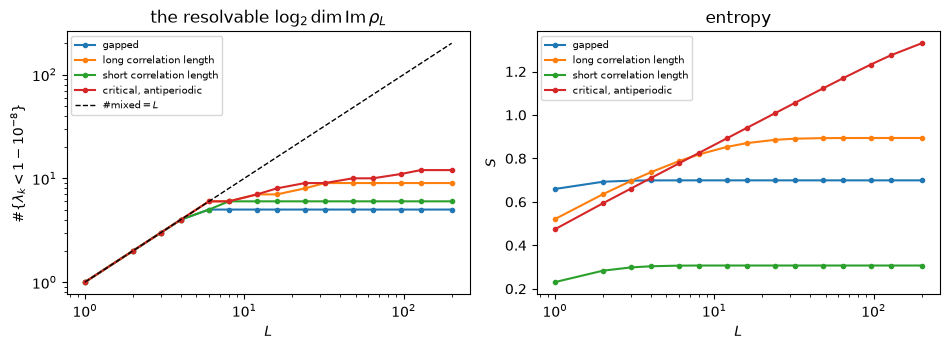

In [2]:
def majorana_matrix(terms: list[tuple[int, int, complex]], num_majoranas: int,
                    device: torch.device = torch.device('cuda')) -> Tensor:
    r'''
    Assemble the real antisymmetric $M$ of $H = (i/4)\gamma^T M \gamma$ from the terms
    $\alpha\,\gamma_a\gamma_b$, with every $\alpha$ purely imaginary.
    Args:
        terms: (a, b, alpha) contributions, summed over repeated pairs.
        num_majoranas: dimension of M.
        device: device of the returned matrix.
    Returns:
        The real antisymmetric matrix M.
    Raises:
        ValueError: if a pair repeats a Majorana, or an alpha is not purely imaginary.
    '''
    entries: dict[tuple[int, int], float] = {}
    for a, b, alpha in terms:
        if a == b:
            raise ValueError(f'the pair ({a}, {b}) repeats a Majorana')
        if abs(alpha.real) > 1e-15:
            raise ValueError(f'alpha {alpha} of ({a}, {b}) is not purely imaginary')
        if a > b:
            a, b, alpha = b, a, -alpha
        coefficient = -2j * alpha
        if abs(coefficient.imag) > 1e-15:
            raise ValueError(f'alpha {alpha} of ({a}, {b}) gives a complex M entry')
        entries[(a, b)] = entries.get((a, b), 0.0) + coefficient.real
    matrix = torch.zeros((num_majoranas, num_majoranas), dtype=REAL, device=device)
    index = torch.tensor(list(entries), dtype=torch.long, device=device).reshape(-1, 2)
    values = torch.tensor(list(entries.values()), dtype=REAL, device=device)
    matrix[index[:, 0], index[:, 1]] = values
    return matrix - matrix.T


def kitaev_terms(num_sites: int, w: float = 1.0, delta: float = 1.0, mu: float = 0.0,
                 flux: bool = False) -> list[tuple[int, int, complex]]:
    r'''
    Terms of the Kitaev chain on a ring, site j on the Majoranas (2j, 2j+1).
    Args:
        num_sites: number of sites.
        w: hopping.
        delta: pairing.
        mu: chemical potential.
        flux: negate the wrap bond, i.e. antiperiodic boundary conditions.
    Returns:
        The (a, b, alpha) terms.
    '''
    terms = []
    for j in range(num_sites):
        jp = (j + 1) % num_sites
        sign = -1.0 if flux and j == num_sites - 1 else 1.0
        terms += [(2 * j, 2 * j + 1, -0.5j * mu),
                  (2 * j, 2 * jp + 1, sign * (-0.5j * w)),
                  (2 * jp, 2 * j + 1, sign * (-0.5j * w)),
                  (2 * j, 2 * jp + 1, sign * (0.5j * delta)),
                  (2 * jp, 2 * j + 1, sign * (-0.5j * delta))]
    return terms


NUM_SITES = 600
LENGTHS = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96, 128, 200]
RINGS = {'gapped': (1.0, False), 'long correlation length': (1.9, False),
         'short correlation length': (3.0, False), 'critical, antiperiodic': (2.0, True)}
blocks = {}
for label, (mu, flux) in RINGS.items():
    covariance = GfPEPS.from_hamiltonian(
        majorana_matrix(kitaev_terms(NUM_SITES, mu=mu, flux=flux), 2 * NUM_SITES)).tensors[0]
    blocks[label] = {length: patch_covariance(covariance, list(range(length)))
                     for length in LENGTHS}

print(f'{"ring":>26} {"S(200)":>8} '
      + ' '.join(f'{t:>6.0e}' for t in TOLERANCES[1::2]))
for label, curves in blocks.items():
    print(f'{label:>26} {entropy(curves[200]):>8.4f} '
          + ' '.join(f'{counts_at(curves[200])[t]:>6}' for t in TOLERANCES[1::2]))

figure, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
for label, curves in blocks.items():
    axes[0].plot(LENGTHS, [mixed_count(curves[length]) for length in LENGTHS],
                 marker='.', label=label)
    axes[1].plot(LENGTHS, [entropy(curves[length]) for length in LENGTHS],
                 marker='.', label=label)
axes[0].plot([1, 200], [1, 200], 'k--', lw=1, label=r'$\#\mathrm{mixed} = L$')
axes[0].set(xscale='log', yscale='log', xlabel='$L$',
            ylabel=r'$\#\{\lambda_k < 1 - 10^{-8}\}$',
            title=r'the resolvable $\log_2\dim\mathrm{Im}\,\rho_L$')
axes[1].set(xscale='log', xlabel='$L$', ylabel='$S$', title='entropy')
for axis in axes:
    axis.legend(fontsize=7)
figure.tight_layout()
plt.show()

## 2. Three lattices, gapped and gapless

`FreeFermion/geometry.py` describes a lattice the way the code needs it:

* `vectors` -- the two **primitive vectors** $a_1, a_2$ that generate the lattice by
  translation;
* `basis` -- the sites inside one **unit cell**, as offsets from the cell's origin: one site
  for the square and triangular lattices, two for the honeycomb;
* `bonds` -- the nearest neighbours, each pair once, written translation-invariantly as
  (basis site $i$, basis site $j$, the cell offset of $j$), so that one list describes every
  size;
* `colors` -- a colour per site for the standard patterns of the lattice, and `potential`,
  which turns such a colouring into on-site values and refuses a rule that does not close on a
  periodic direction, where it would leave a seam.

`square(n1, n2)`, `honeycomb(...)` and `triangular(...)` return one finite instance, a
**geometry**, with one **boundary condition per direction**: a direction is *open* (it ends,
and the bonds that would leave it are dropped) or *periodic* (it closes on itself).  The three
constructors are periodic in both directions; `.rectangle`, `.cylinder` and `.torus` name the
combination explicitly.  A geometry lists its sites as
`site = per_cell * (i + n1 * j) + basis`, with `i, j` the integer coordinates of the cell and
`basis` the site inside it, so every site keeps a stable label and owns the Majoranas $2r$ and
$2r+1$.

One orbital per site, nearest-neighbour hopping $t = 1$, and a potential that opens a gap:

| lattice | potential | filled states | gap at that filling |
|---|---|---|---|
| square | checkerboard $\pm V$ | $1/2$ | $2V$ |
| honeycomb | Semenoff $\pm V$ | $1/2$ | $2V$ |
| triangular | three-colouring $(V, V, -2V)$ | $1/3$ | $2V$ |

The first two patterns give the two sublattices $\pm V$; the third gives one of the three
sublattices $-2V$ and the other two $+V$, so its mean potential is zero.

The **Fermi sea** is the same lattice with the potential switched off, at filling $3/8$: fill
every eigenstate of the single-particle matrix below the chemical potential, so that the Fermi
level sits on a Fermi surface and the correlations are a power law instead of exponential.
The state is built from the single-particle matrix $X$ (hopping plus potential, shifted by
$\mu$) as follows.  With the projector
$P = \sum_{\varepsilon<0}|u_\varepsilon\rangle\langle u_\varepsilon|$ on the filled states,
$Q = 2P - 1$, and the Majoranas $a_r = c_r + c_r^\dagger$,
$b_r = -i(c_r - c_r^\dagger)$, the covariance is $\Gamma_{2r,2r'+1} = Q_{rr'}$ and
$\Gamma_{2r+1,2r'} = -Q_{rr'}$.  The next cell checks that against the exact ground state of a
small lattice in its Fock space, since getting the interleaving of the Majoranas wrong is
quiet.

In [3]:
@dataclass(frozen=True)
class Model:
    '''One state of the notebook: a lattice, an optional gapped pattern, and a filling.'''
    name: str
    build: Callable[[int], Geometry]     # cells along a2 -> geometry, with 24 cells along a1
    pattern: str | None                  # None: no potential, i.e. a Fermi sea
    amplitude: float
    filling: float


@dataclass(frozen=True)
class State:
    '''A built state: the geometry, its on-site potential, its covariance and its filling.'''
    grid: Geometry
    potential: Tensor
    covariance: Tensor
    filling: float


MODELS = (
    Model('square', lambda n2: square(24, n2), 'checkerboard', 0.5, 0.5),
    Model('honeycomb', lambda n2: honeycomb(24, n2), 'semenoff', 0.5, 0.5),
    Model('triangular', lambda n2: triangular(24, n2), 'three-colouring', 1.0, 1.0 / 3.0),
    Model('square sea', lambda n2: square(24, n2), None, 0.0, 3.0 / 8.0),
    Model('honeycomb sea', lambda n2: honeycomb(24, n2), None, 0.0, 3.0 / 8.0),
    Model('triangular sea', lambda n2: triangular(24, n2), None, 0.0, 3.0 / 8.0),
)


def colouring_rule(kind: str, amplitude: float):
    '''
    The on-site rule of one gapped pattern, a function of the cell and the basis site so
    that geometry can check that it closes on a periodic direction.
    Args:
        kind: 'checkerboard', 'semenoff' or 'three-colouring'.
        amplitude: V of the pattern.
    Returns:
        rule(cell, basis) -> values.
    '''
    if kind == 'checkerboard':
        return lambda cell, basis: torch.where((cell[:, 0] + cell[:, 1]) % 2 == 0,
                                               amplitude, -amplitude)
    if kind == 'semenoff':
        return lambda cell, basis: torch.where(basis == 0, amplitude, -amplitude)
    return lambda cell, basis: torch.where((cell[:, 0] - cell[:, 1]) % 3 == 2,
                                           -2.0 * amplitude, amplitude)


def single_particle(grid: Geometry, potential: Tensor, hopping: float = 1.0,
                    mu: float = 0.0) -> Tensor:
    '''
    Real symmetric single-particle matrix of -t hopping plus the potential shifted by mu.
    Args:
        grid: the geometry.
        potential: on-site value per site.
        hopping: hopping amplitude.
        mu: chemical potential.
    Returns:
        The symmetric matrix X.
    '''
    matrix = torch.diag(potential - mu)
    for r, rp in grid.bonds:
        matrix[r, rp] = matrix[r, rp] - hopping
        matrix[rp, r] = matrix[rp, r] - hopping
    return matrix


def slater_covariance(grid: Geometry, potential: Tensor, mu: float,
                      hopping: float = 1.0) -> Tensor:
    '''
    Covariance of the Fermi sea of X - mu, interleaved so that site r owns 2r and 2r+1.
    Args:
        grid: the geometry.
        potential: on-site value per site.
        mu: chemical potential.
        hopping: hopping amplitude.
    Returns:
        The pure real antisymmetric covariance, shape (2 * sites, 2 * sites).
    '''
    matrix = single_particle(grid, potential, hopping, mu).to(torch.device('cuda'))
    values, vectors = torch.linalg.eigh(matrix)
    filled = vectors[:, values < 0.0]
    block = 2.0 * (filled @ filled.T) - torch.eye(matrix.shape[0], dtype=matrix.dtype,
                                                  device=matrix.device)
    covariance = torch.zeros((2 * matrix.shape[0], 2 * matrix.shape[0]), dtype=matrix.dtype,
                             device=matrix.device)
    covariance[0::2, 1::2] = block
    covariance[1::2, 0::2] = -block
    return covariance


def choose_mu(grid: Geometry, potential: Tensor, filling: float,
              hopping: float = 1.0) -> float:
    '''
    Chemical potential at the centre of the level gap that holds the given filling.
    Args:
        grid: the geometry.
        potential: on-site value per site.
        filling: electrons per site, an integer count of the states.
        hopping: hopping amplitude.
    Returns:
        The chemical potential.
    Raises:
        ValueError: if the filling is not an integer count of the states.
    '''
    occupied = round(filling * grid.sites)
    if abs(filling * grid.sites - occupied) > 1e-9 or not 0 < occupied < grid.sites:
        raise ValueError(f'filling {filling} of {grid.sites} sites is not an integer count')
    spectrum = torch.linalg.eigvalsh(single_particle(grid, potential, hopping, 0.0)
                                     .to(torch.complex128)).real
    return 0.5 * float(spectrum[occupied - 1] + spectrum[occupied])


def gap(grid: Geometry, potential: Tensor, filling: float) -> float:
    '''
    The distance between the two single-particle levels that straddle the Fermi level: zero
    when the Fermi level sits on a Fermi surface, $2V$ for the gapped patterns above.
    Args:
        grid: the geometry.
        potential: on-site value per site.
        filling: electrons per site.
    Returns:
        The gap.
    '''
    occupied = round(filling * grid.sites)
    spectrum = torch.linalg.eigvalsh(single_particle(grid, potential)
                                     .to(torch.complex128)).real
    return float(spectrum[occupied] - spectrum[occupied - 1])


def build_state(model: Model, n2: int = 36) -> State:
    '''
    Build one state of MODELS on 24 x n2 cells.
    Args:
        model: the model to build.
        n2: cells along a2.
    Returns:
        The State.
    '''
    grid = model.build(n2)
    if model.pattern is None:
        potential = torch.zeros(grid.sites, dtype=REAL)
    else:
        potential = grid.potential(colouring_rule(model.pattern, model.amplitude))
    mu = choose_mu(grid, potential, model.filling)
    return State(grid, potential, slater_covariance(grid, potential, mu), model.filling)

In [4]:
import functools

Z = torch.tensor([[1, 0], [0, -1]], dtype=torch.complex128)
LOWER = torch.tensor([[0, 1], [0, 0]], dtype=torch.complex128)
EYE = torch.eye(2, dtype=torch.complex128)
operator = lambda n, r, single: functools.reduce(
    torch.kron, [Z] * r + [single] + [EYE] * (n - r - 1))

small = square(2, 4)
sites = small.sites
potential = small.potential(colouring_rule('checkerboard', 0.5)) + torch.tensor(
    [0.17 * math.cos(2 * math.pi * (site // 2) / 3)
     + 0.11 * math.sin(2 * math.pi * (site % 2) / 3) for site in range(sites)])
spectrum = torch.linalg.eigvalsh(single_particle(small, potential).to(torch.complex128)).real
mu = 0.5 * float(spectrum[sites // 2 - 1] + spectrum[sites // 2])

annihilation = [operator(sites, site, LOWER) for site in range(sites)]
creation = [c.conj().T for c in annihilation]
hamiltonian = sum(float(single_particle(small, potential, 1.0, mu)[r, rp])
                  * (creation[r] @ annihilation[rp])
                  for r in range(sites) for rp in range(sites))
ground = torch.linalg.eigh(hamiltonian)[1][:, 0]
majoranas = []
for site in range(sites):
    majoranas += [annihilation[site] + creation[site],
                  -1j * (annihilation[site] - creation[site])]
exact = torch.zeros((2 * sites, 2 * sites), dtype=torch.float64)
for a in range(2 * sites):
    for b in range(2 * sites):
        if a != b:
            exact[a, b] = float((1j * (ground.conj() @ (majoranas[a] @ majoranas[b])
                                       @ ground)).real)

print('max |Fock ground state - slater_covariance| =',
      float((exact - slater_covariance(small, potential, mu).cpu()).abs().max()))

max |Fock ground state - slater_covariance| = 1.6653345369377348e-15


          model  sites     gap   pure
         square    864  1.0000   True


      honeycomb   1728  1.0000   True
     triangular    864  2.0000   True


     square sea    864  0.0000   True


  honeycomb sea   1728  0.0000   True
 triangular sea    864  0.0000   True
          model   w  cut         S  1e-04  1e-08  1e-12


         square   8   48   15.0281    102    158    186


...

     triangular  17   96   11.1558     64    156    212
     square sea   8   48   24.3867    105    131    140


     square sea  17   48   27.2165    129    185    201


  honeycomb sea   8   48   34.6916    172    258    318


  honeycomb sea  17   48   38.8301    192    300    404
 triangular sea   8   96   23.2761    104    134    136


 triangular sea  17   96   25.7646    123    191    231


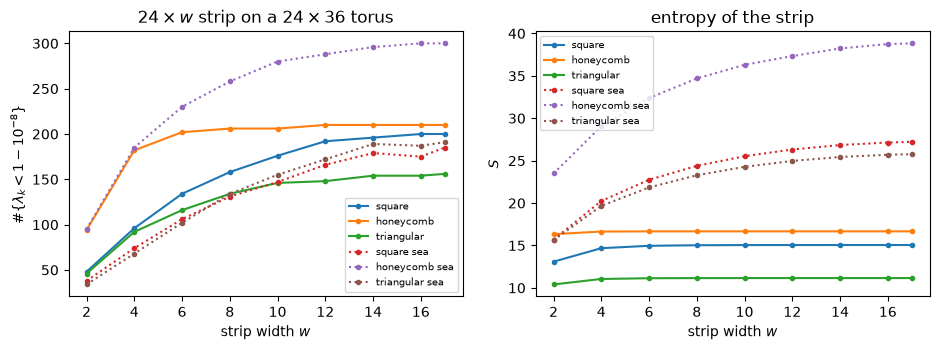

In [5]:
built = {model.name: build_state(model) for model in MODELS}

print(f'{"model":>15} {"sites":>6} {"gap":>7} {"pure":>6}')
for model in MODELS:
    state = built[model.name]
    print(f'{model.name:>15} {state.grid.sites:>6} '
          f'{gap(state.grid, state.potential, state.filling):>7.4f} '
          f'{str(is_pure(state.covariance)):>6}')

figure, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
WIDTHS = (2, 4, 6, 8, 10, 12, 14, 16, 17)
print(f'{"model":>15} {"w":>3} {"cut":>4} {"S":>9} '
      + ' '.join(f'{t:>6.0e}' for t in TOLERANCES[1::2]))
for model in MODELS:
    state = built[model.name]
    counts, entropies = [], []
    for width in WIDTHS:
        patch = state.grid.patch(state.grid.n1, width)
        block = patch_covariance(state.covariance, patch)
        counts.append(mixed_count(block))
        entropies.append(entropy(block))
        if width in (8, 17):
            print(f'{model.name:>15} {width:>3} {state.grid.cut_bonds(patch):>4} '
                  f'{entropy(block):>9.4f} '
                  + ' '.join(f'{counts_at(block)[t]:>6}' for t in TOLERANCES[1::2]))
    style = ':' if model.pattern is None else '-'
    axes[0].plot(WIDTHS, counts, style, marker='.', label=model.name)
    axes[1].plot(WIDTHS, entropies, style, marker='.', label=model.name)
axes[0].set(xlabel='strip width $w$', ylabel=r'$\#\{\lambda_k < 1 - 10^{-8}\}$',
            title=r'$24 \times w$ strip on a $24 \times 36$ torus')
axes[1].set(xlabel='strip width $w$', ylabel='$S$', title='entropy of the strip')
for axis in axes:
    axis.legend(fontsize=7)
figure.tight_layout()
plt.show()

## 3. The boundary, not the area

The measure of a patch's boundary throughout is the number of **cut bonds**: lattice bonds
with one endpoint in the patch and the other outside it.  A $4 \times 12$ parallelogram of the
square lattice cuts 32 of them, while the snake-shaped prefix of section 4 at half filling cuts
6, which is why patches of a similar size can differ.  The **depth per cut bond** quoted below
is the count divided by the number of cut bonds: how many mixed modes one bond of boundary
carries.

Two measurements follow.  The first holds the area -- or the perimeter -- of a parallelogram
patch fixed and varies the other, so that a count proportional to the perimeter can be told
from one proportional to the area.  The second grows the torus at a fixed patch: a finite
correlation length has to leave the count where it is, a Fermi surface has to let it grow with
the length.

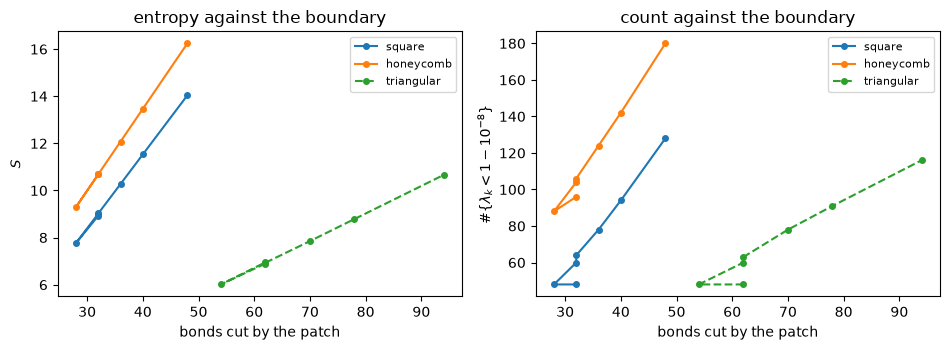

          model   a x b  area  cut         S #mixed(1e-8)
         square    4x12    48   32    8.9285           48
         square     6x8    48   28    7.7674           48
         square    6x10    60   32    9.0143           60
         square     8x8    64   32    9.0232           64
         square    8x10    80   36   10.2760           78
         square   10x10   100   40   11.5310           94
         square   12x12   144   48   14.0397          128
      honeycomb    4x12    96   32   10.6791           96
      honeycomb     6x8    96   28    9.2993           88
      honeycomb    6x10   120   32   10.6879          104
      honeycomb     8x8   128   32   10.6885          106
      honeycomb    8x10   160   36   12.0773          124
      honeycomb   10x10   200   40   13.4662          142
      honeycomb   12x12   288   48   16.2438          180
     triangular    4x12    48   62    6.8964           48
     triangular     6x8    48   54    6.0111           48
     triangula

         square   36   15.0281          158         3.292


         square   48   15.0281          158         3.292


         square   72   15.0281          158         3.292


      honeycomb   24   16.6653          206         4.292


...

  honeycomb sea   48   35.2590          265         5.521


  honeycomb sea   72   33.0215          257         5.354
 triangular sea   24   22.6705          132         1.375


 triangular sea   36   23.2761          134         1.396


 triangular sea   48   24.3691          136         1.417


 triangular sea   72   23.6079          134         1.396


In [6]:
@dataclass(frozen=True)
class Record:
    '''One patch and what the state makes of it.'''
    cut: int
    sites: int
    entropy: float
    counts: dict[float, int]


SHAPES = ((4, 12), (6, 8), (6, 10), (8, 8), (8, 10), (10, 10), (12, 12))
records = {}
for model in MODELS:
    state = built[model.name]
    records[model.name] = []
    for a, b in SHAPES:
        patch = state.grid.patch(a, b)
        block = patch_covariance(state.covariance, patch)
        records[model.name].append(Record(state.grid.cut_bonds(patch), len(patch),
                                          entropy(block), counts_at(block)))

figure, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
for model in MODELS:
    if model.pattern is None:
        continue
    rows = records[model.name]
    style = '--' if model.name == 'triangular' else '-'
    axes[0].plot([row.cut for row in rows], [row.entropy for row in rows], style,
                 marker='o', ms=4, label=model.name)
    axes[1].plot([row.cut for row in rows], [row.counts[QUOTED] for row in rows], style,
                 marker='o', ms=4, label=model.name)
axes[0].set(xlabel='bonds cut by the patch', ylabel='$S$',
            title='entropy against the boundary')
axes[1].set(xlabel='bonds cut by the patch', ylabel=r'$\#\{\lambda_k < 1 - 10^{-8}\}$',
            title='count against the boundary')
for axis in axes:
    axis.legend(fontsize=8)
figure.tight_layout()
plt.show()

print(f'{"model":>15} {"a x b":>7} {"area":>5} {"cut":>4} {"S":>9} {"#mixed(1e-8)":>12}')
for model in MODELS:
    for row, (a, b) in zip(records[model.name], SHAPES):
        print(f'{model.name:>15} {f"{a}x{b}":>7} {row.sites:>5} {row.cut:>4} '
              f'{row.entropy:>9.4f} {row.counts[QUOTED]:>12}')

print(f'\n{"model":>15} {"L":>4} {"S":>9} {"#mixed(1e-8)":>12} {"per cut bond":>13}')
for model in MODELS:
    for length in (24, 36, 48, 72):
        state = build_state(model, length)
        patch = state.grid.patch(24, 8)
        block = patch_covariance(state.covariance, patch)
        cut = state.grid.cut_bonds(patch)
        print(f'{model.name:>15} {length:>4} {entropy(block):>9.4f} '
              f'{mixed_count(block):>12} {mixed_count(block) / cut:>13.3f}')

    square: saturation 1e-02:54 1e-04:112 1e-06:152 1e-08:200 1e-10:242 1e-12:268, depth per cut bond 1e-02:1.12 1e-04:2.33 1e-06:3.17 1e-08:4.17 1e-10:5.04 1e-12:5.58


 honeycomb: saturation 1e-02:78 1e-04:102 1e-06:178 1e-08:210 1e-10:274 1e-12:322, depth per cut bond 1e-02:1.62 1e-04:2.12 1e-06:3.71 1e-08:4.38 1e-10:5.71 1e-12:6.71


triangular: saturation 1e-02:32 1e-04:66 1e-06:116 1e-08:156 1e-10:186 1e-12:216, depth per cut bond 1e-02:0.33 1e-04:0.69 1e-06:1.21 1e-08:1.62 1e-10:1.94 1e-12:2.25


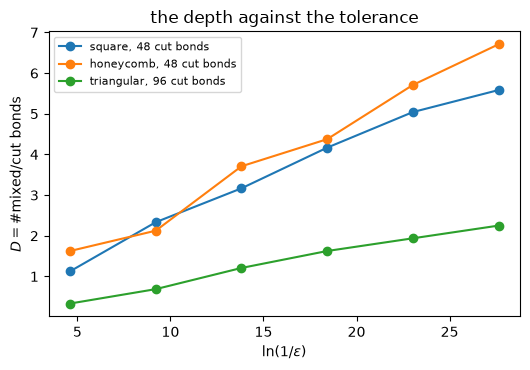


    lattice     gap  D(1e-8)   dD/dln(1/eps)
     square  1.0000     4.17           0.194


  honeycomb  1.0000     4.38           0.221
 triangular  2.0000     1.62           0.083


In [7]:
figure, axis = plt.subplots(figsize=(5.4, 3.8))
depth = {}
for model in MODELS:
    if model.pattern is None:
        continue
    state = built[model.name]
    saturation = {t: 0 for t in TOLERANCES}
    for width in range(2, (state.grid.n2 - 1) // 2 + 1):
        counts = counts_at(patch_covariance(state.covariance,
                                            state.grid.patch(state.grid.n1, width)))
        saturation = {t: max(saturation[t], counts[t]) for t in TOLERANCES}
    cut = state.grid.cut_bonds(state.grid.patch(state.grid.n1, 8))
    depth[model.name] = {t: saturation[t] / cut for t in TOLERANCES}
    axis.plot([math.log(1 / t) for t in TOLERANCES],
              [depth[model.name][t] for t in TOLERANCES],
              marker='o', label=f'{model.name}, {cut} cut bonds')
    print(f'{model.name:>10}: saturation '
          + ' '.join(f'{t:.0e}:{saturation[t]}' for t in TOLERANCES)
          + ', depth per cut bond '
          + ' '.join(f'{t:.0e}:{depth[model.name][t]:.2f}' for t in TOLERANCES))
axis.set(xlabel=r'$\ln(1/\epsilon)$', ylabel=r'$D = \#\mathrm{mixed}/\mathrm{cut\ bonds}$',
         title='the depth against the tolerance')
axis.legend(fontsize=8)
figure.tight_layout()
plt.show()

print(f'\n{"lattice":>11} {"gap":>7} {"D(1e-8)":>8} {"dD/dln(1/eps)":>15}')
for model in MODELS:
    if model.pattern is None:
        continue
    state = built[model.name]
    slopes = [(depth[model.name][TOLERANCES[index + 1]] - depth[model.name][TOLERANCES[index]])
              / (math.log(1 / TOLERANCES[index + 1]) - math.log(1 / TOLERANCES[index]))
              for index in range(len(TOLERANCES) - 1)]
    print(f'{model.name:>11} {gap(state.grid, state.potential, state.filling):>7.4f} '
          f'{depth[model.name][QUOTED]:>8.2f} {sum(slopes) / len(slopes):>15.3f}')

## 4. The same covariance as a `GfPEPS`

`GfPEPS` stores the state as a **network**: one **node** per site, each node carrying the
site's two external (physical) Majorana modes plus one **bond** for every lattice bond it is
part of.  A bond is a group of **virtual** Majorana modes shared by its two nodes, and its
**bond dimension** is how many modes it carries.  A **leg** is one such group of modes inside a
node; a node's covariance is stored as blocks keyed by the pair of legs a block connects, so
that dropping a bond drops exactly the entries that used it.

Contracting a bond projects the bond modes of the two nodes onto the EPR state
$\prod_k (1 + i\gamma_k\upsilon_k)/2$ (Eq. (9) of arXiv:2012.04666), the fermionic analogue
of a maximally entangled pair of the two sets of modes.  `partial_trace` on a set of nodes
contracts every bond first and then keeps the sub-block of those nodes, which is the exact
reduced state of that patch.

`Geometry.attach` binds a network to a geometry on demand: it records once which node, and
which of that node's external modes, is which site, and returns a `Bound`.
`Bound.covariance()` gives the whole state in the physical layout of the geometry, and
`Bound.reduced(patch)` gives the covariance of a patch of sites through `partial_trace`, so a
patch is written as a list of sites everywhere.

The bond dimension a network needs is fixed by the state, not by the geometry.  Across a cut
the **Schmidt rank** of the state -- the number of independent states the two sides can be in,
$2$ to the number of mixed modes across the cut -- cannot exceed what the bonds can carry,
$2^{\sum\mathrm{bond\_dim}/2}$, so $\sum \mathrm{bond\_dim} \ge 2\,\#\mathrm{mixed}$ over the
bonds that cross the cut; `Geometry.cut_bonds` counts those bonds.

In [8]:
state = built['square']
strip = state.grid.patch(state.grid.n1, 8)
mixed = mixed_count(patch_covariance(state.covariance, strip))
cut = state.grid.cut_bonds(strip)
per_bond = math.ceil(2 * mixed / cut)
print(f'the 24 x 8 strip of the square torus cuts {cut} bonds and carries {mixed} mixed '
      f'modes at 1e-8, so a network on the lattice graph needs at least {2 * mixed} '
      f'Majorana modes over them, {per_bond} per bond '
      f'({per_bond + per_bond % 2} to keep it even)')

small = build_state(MODELS[0], 8)
bound = small.grid.attach(GfPEPS.from_global_covariance(small.covariance),
                          node_of_site=[0] * small.grid.sites,
                          mode_of_site=[2 * site for site in range(small.grid.sites)])
patch = small.grid.patch(4, 4, 2, 2)
majoranas = sorted(2 * site + odd for site in patch for odd in (0, 1))
print(f'Bound on 8 x 8: whole covariance deviation '
      f'{float((bound.covariance() - small.covariance).abs().max()):.1e}, patch of '
      f'{len(patch)} sites deviation '
      f'{float((bound.reduced(patch) - small.covariance[majoranas][:, majoranas]).abs().max()):.1e}, '
      f'cut bonds {small.grid.cut_bonds(patch)}, '
      f'cut length {small.grid.cut_length(patch):.3f}')

the 24 x 8 strip of the square torus cuts 48 bonds and carries 158 mixed modes at 1e-8, so a network on the lattice graph needs at least 316 Majorana modes over them, 7 per bond (8 to keep it even)
Bound on 8 x 8: whole covariance deviation 0.0e+00, patch of 16 sites deviation 0.0e+00, cut bonds 16, cut length 16.000


## What the cells measured

* One dimension: a gapped ring gives a count that stops growing with $L$ -- single digits at
  $\epsilon = 10^{-8}$ for $L$ up to 200 -- while the antiperiodic ring, the critical one,
  keeps growing with $L$ and its entropy grows with $\ln L$.
* Two dimensions, gapped: at a fixed tolerance the count follows the number of cut bonds and
  not the area, and it does not move when the torus grows at a fixed patch.  The depth per cut
  bond grows with $\ln(1/\epsilon)$ over the three decades measured, and it is the smaller on
  the lattice with the larger gap ($V = 1$ on the triangular lattice, gap $2V = 2$, against
  $V = 0.5$ on the square and honeycomb, gap $1$).  Two gaps and three tolerances are not
  enough to fit the prefactor, and none is claimed.
* Two dimensions, Fermi sea: the count of a strip keeps growing with its width and drifts with
  the length of the torus, and the entropy per cut bond is far larger -- with no gap the
  correlations reach across the whole system.
* For `GaussianCGO` the count is `size = 2**len(mixed)` and `CGO.py` estimates its SDP at
  $16\,\mathrm{rank}^4$: the cost of a patch is set by its boundary, and the tolerance is the
  knob on that cost, because the depth enters only through $\ln(1/\epsilon)$.
